Dea Kayla P. D. / 3323600005 / 3 Sains Data Terapan A

# Import Library

In [1]:
import pandas as pd
import nltk 
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dea\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dea\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Data

In [2]:
df = pd.read_csv('tiktok.csv')
df

,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,videoWebUrl,uid,cid,avatarThumbnail
0,kaaa habis berapa buat urus berkas sampe kesan...,40,4.0,2025-08-29T10:57:40.000Z,youuu_78,https://www.tiktok.com/@nadaikaa/video/7538096...,7394773664187171846,7543959970715288327,https://p16-common-sign-sg.tiktokcdn-us.com/to...
1,kaa mau template essaynya kakk,0,0.0,2025-09-02T15:27:02.000Z,milkyjenoo,https://www.tiktok.com/@nadaikaa/video/7538096...,7004355353115264026,7545513703606862610,https://p16-common-sign-sg.tiktokcdn-us.com/to...
2,"ESSAY, MW KAAAA😼😼😼🩷🩷",0,0.0,2025-08-29T23:41:26.000Z,mrsmllaowk,https://www.tiktok.com/@nadaikaa/video/7538096...,7277175629743932417,7544156737549927176,https://p16-common-sign-sg.tiktokcdn-us.com/to...
3,"kakk klo anak gapyear bisa gaa?, perlu cantumi...",0,0.0,2025-09-02T16:15:40.000Z,cherryblup_,https://www.tiktok.com/@nadaikaa/video/7538096...,6733450414497170434,7545526254515536648,https://p19-common-sign-sg.tiktokcdn-us.com/to...
4,kak nilainya berapa aja kak😅,10,0.0,2025-08-31T10:51:50.000Z,nasyiwa.aqila,https://www.tiktok.com/@nadaikaa/video/7538096...,7213020009763881986,7544700615342146322,https://p16-common-sign-va.tiktokcdn-us.com/to...
...,...,...,...,...,...,...,...,...,...
220,"kalo bisa tuh video gini, langsung terbayang s...",1,0.0,2025-01-29T10:50:40.000Z,earthoooc,https://www.tiktok.com/@aisyahrendusara/video/...,6896793919365006338,7465288048465412882,https://p16-common-sign-sg.tiktokcdn-us.com/to...
221,masi ga percaya 😭 ini biaya hidup gitu” gimana...,3,NaN,2025-05-15T11:47:18.000Z,onmywayyies,https://www.tiktok.com/@ieltspresso/video/7502...,7235242315269784581,7504637669601231623,https://p16-sign-sg.tiktokcdn.com/tos-alisg-av...
222,harus tes ielts sm toffel dlu pasti,0,NaN,2025-06-04T09:23:42.000Z,user592248224,https://www.tiktok.com/@ieltspresso/video/7502...,7449344527397913607,7512022404383326977,https://p16-sign-sg.tiktokcdn.com/tos-alisg-av...
223,iyaa pake ielts,0,NaN,2025-05-11T07:48:10.000Z,redcasper7,https://www.tiktok.com/@ieltspresso/video/7502...,6882418102789850113,7503091726928773906,https://p16-common-sign-va.tiktokcdn-us.com/to...


# Check Missing Values

Memeriksa apakah terdapat data yang hilang (NaN) dalam dataset menggunakan df,info().
Outputnya menunjukkan bahwa kolom replyCommentTotal memiliki nilai yang hilang
sebanyak 47 baris (178 non-null dari 225 total baris)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               225 non-null    object 
 1   diggCount          225 non-null    int64  
 2   replyCommentTotal  178 non-null    float64
 3   createTimeISO      225 non-null    object 
 4   uniqueId           225 non-null    object 
 5   videoWebUrl        225 non-null    object 
 6   uid                225 non-null    int64  
 7   cid                225 non-null    int64  
 8   avatarThumbnail    225 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 15.9+ KB


# Handling Missing Values

Untuk menangani data yang hilang dalam dataset, saya gunakan fungsi fillna untuk
mengganti nilai NaN dengan angka 0 karena NaN pada kolom tersebut mengartikan tidak
ada balasan komentar. Output dari df.info() kedua menunjukkan bahwa kolom
replyCommentTotal sudah terisi

In [4]:
df['replyCommentTotal'].fillna(0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               225 non-null    object 
 1   diggCount          225 non-null    int64  
 2   replyCommentTotal  225 non-null    float64
 3   createTimeISO      225 non-null    object 
 4   uniqueId           225 non-null    object 
 5   videoWebUrl        225 non-null    object 
 6   uid                225 non-null    int64  
 7   cid                225 non-null    int64  
 8   avatarThumbnail    225 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 15.9+ KB


C:\Users\Dea\AppData\Local\Temp\ipykernel_24060\818054576.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['replyCommentTotal'].fillna(0, inplace=True)


# DateTime

Pada kolom createTimeISO berisi informasi waktu dalam bentuk teks. Maka, diubah ke
datetime terlebih dahulu dikarenakan analisis yang akan dilakukan adalah User Behavior
Analysis. Menggunakan fungsi pd.to_datetime() untuk mengonversi. Setelah itu,
jam_interaksi dan hari_interaksi diekstrak dari kolom datetime yang baru

In [5]:
df['waktu_interaksi'] = pd.to_datetime(df['createTimeISO'])
df['jam_interaksi'] = df['waktu_interaksi'].dt.hour
df['hari_interaksi'] = df['waktu_interaksi'].dt.day_name()
print(df[['waktu_interaksi', 'jam_interaksi', 'hari_interaksi']])

              waktu_interaksi  jam_interaksi hari_interaksi
0   2025-08-29 10:57:40+00:00             10         Friday
1   2025-09-02 15:27:02+00:00             15        Tuesday
2   2025-08-29 23:41:26+00:00             23         Friday
3   2025-09-02 16:15:40+00:00             16        Tuesday
4   2025-08-31 10:51:50+00:00             10         Sunday
..                        ...            ...            ...
220 2025-01-29 10:50:40+00:00             10      Wednesday
221 2025-05-15 11:47:18+00:00             11       Thursday
222 2025-06-04 09:23:42+00:00              9      Wednesday
223 2025-05-11 07:48:10+00:00              7         Sunday
224 2025-06-02 03:40:54+00:00              3         Monday

[225 rows x 3 columns]


Tiga kolom berhasil dibuat yaitu waktu_interaksi, jam_interaksi, dan hari_interaksi. Data ini
akan digunakan untuk menganalisis pola aktivitas pengguna berdasarkan jam dan harinya.
Contohnya pada baris nomor 2, waktu interaksinya pada tanggal 29 Agustus 2025 pukul
23:41:26 yang pada jam interaksinya pukul 23 yaitu jam 11 malam dan hari interaksinya
pada hari jum’at.

# Text Cleaning

Melakukan cleaning awal pada data text dengan mengubah semua hurufnya menjadi huruf
kecil dan menghapus karakter yang tidak relevan seperti tanda baca, angka, dan emoji.

In [6]:
df['text_bersih'] = df['text'].astype(str).str.lower()
df['text_bersih'] = df['text_bersih'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
df[['text', 'text_bersih']]

,text,text_bersih
0,kaaa habis berapa buat urus berkas sampe kesan...,kaaa habis berapa buat urus berkas sampe kesan...
1,kaa mau template essaynya kakk,kaa mau template essaynya kakk
2,"ESSAY, MW KAAAA😼😼😼🩷🩷",essay mw kaaaa
3,"kakk klo anak gapyear bisa gaa?, perlu cantumi...",kakk klo anak gapyear bisa gaa perlu cantumin ...
4,kak nilainya berapa aja kak😅,kak nilainya berapa aja kak
...,...,...
220,"kalo bisa tuh video gini, langsung terbayang s...",kalo bisa tuh video gini langsung terbayang se...
221,masi ga percaya 😭 ini biaya hidup gitu” gimana...,masi ga percaya ini biaya hidup gitu gimanaa ka
222,harus tes ielts sm toffel dlu pasti,harus tes ielts sm toffel dlu pasti
223,iyaa pake ielts,iyaa pake ielts


Outputnya menunjukkan teksnya lebih bersih dari teks aslinya. Contohnya, komentar
“ESSAY, MW KAAAA😼😼😼🩷🩷” berhasil diubah menjadi “essay mw kaaaa”

# Tokenization

Memecah kalimat atau teks yang sudah bersih menjadi kata individual yang disebut token.
Menggunakan fungsi word_tokenize yang akan diterapkan pada kolom text_bersih.

In [7]:
df['text_tokenized'] = df['text_bersih'].apply(lambda x: word_tokenize(x))
df[['text_bersih', 'text_tokenized']]

,text_bersih,text_tokenized
0,kaaa habis berapa buat urus berkas sampe kesan...,"[kaaa, habis, berapa, buat, urus, berkas, samp..."
1,kaa mau template essaynya kakk,"[kaa, mau, template, essaynya, kakk]"
2,essay mw kaaaa,"[essay, mw, kaaaa]"
3,kakk klo anak gapyear bisa gaa perlu cantumin ...,"[kakk, klo, anak, gapyear, bisa, gaa, perlu, c..."
4,kak nilainya berapa aja kak,"[kak, nilainya, berapa, aja, kak]"
...,...,...
220,kalo bisa tuh video gini langsung terbayang se...,"[kalo, bisa, tuh, video, gini, langsung, terba..."
221,masi ga percaya ini biaya hidup gitu gimanaa ka,"[masi, ga, percaya, ini, biaya, hidup, gitu, g..."
222,harus tes ielts sm toffel dlu pasti,"[harus, tes, ielts, sm, toffel, dlu, pasti]"
223,iyaa pake ielts,"[iyaa, pake, ielts]"


Outputnya menunjukkan tiap barisnya telah berhasil menjadi sebuah list dari token.
Contohnya, komentar “essay mw kaaaa” berhasil diubah menjadi [essay, mw, kaaaa]

# Stopword Removal

Menghapus kata-kata umum yang sering muncul namun tidak memiliki makna seperti di,
dan, yang. Tujuannya agar fokus pada kata-kata kunci yang relevan. Disini saya membuat
daftar kata stopwords yang biasanya digunakan oleh banyak orang di TikTok. Setiap token
yang ada di dalam daftar stopwords akan dihapus

In [8]:
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = {'kaaaa', 'kaaa', 'kaa', 'kakk', 'kak', 'ka', 'klo', 'yaa', 'nya', 'nih', 'dong',
    'yg', 'ga', 'aja', 'sih', 'kalo', 'tuh', 'gini', 'gtu', 'gitu', 'gaa', 'gak', 'enggak','yg', 'utk', 'cuman', 'deh', 'Btw', 'tapi', 'gua', 'gue', 'lo', 'lu',
    'kalo', 'trs', 'jd', 'nih', 'ntr', 'nya', 'lg', 'gk', 'ecusli', 'dpt',
    'dr', 'kpn', 'kok', 'kyk', 'donk', 'yah', 'u', 'ya', 'ga', 'km', 'eh',
    'sih', 'eh', 'bang', 'br', 'kyk', 'rp', 'jt', 'kan', 'gpp', 'sm', 'usah',
    'mas', 'sob', 'thx', 'ato', 'jg', 'gw', 'wkwkwk', 'mak', 'haha', 'iy', 'k','t',
    'tp','haha', 'dg', 'dri', 'duh', 'ye', 'wkwk', 'syg', 'btw',
    'nerjemahin', 'gaes', 'guys', 'moga', 'kmrn', 'nemu', 'yukk',
    'wkwkw', 'klas', 'iw', 'ew', 'lho', 'sbnry', 'org', 'gtu', 'bwt',
    'krlga', 'clau', 'lbh', 'cpet', 'ku', 'wke', 'mba', 'mas', 'sdh', 'kmrn',
    'oi', 'spt', 'dlm', 'bs', 'krn', 'jgn', 'sapa', 'spt', 'sh', 'wakakaka',
    'sihhh', 'hehe', 'ih', 'dgn', 'la', 'kl', 'ttg', 'mana', 'kmna', 'kmn',
    'tdk', 'tuh', 'dah', 'kek', 'ko', 'pls', 'bbrp', 'pd', 'mah', 'dhhh',
    'kpd', 'tuh', 'kzl', 'byar', 'si', 'sii', 'cm', 'sy', 'hahahaha', 'weh','n',
    'dlu', 'tuhh','tpi','krn','kl','kbnykn','jd','lah',
    'dong','koq','pdhl','dg','tp','amp','wlpun','pst','tuk',
    'laaah','si','trs','tuh','cuyy','ehem','sih','di','d','kalee','jg','emg','wkwkwkw','anjritt','sih',
    'kok','mbok','nie','sj','ajg','ente','hm','yang','tau','kjmu','gimana','kayak','nggak','klo','dar',
    'aja','rb','emang','karna','gin','ngga','msh','iya','kah','pake','kayanya','gitu','doang','jadi','bangasal'}
stop_words.update(custom_stopwords)
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]
df['text_no_stopwords'] = df['text_tokenized'].apply(remove_stopwords)
df[['text_tokenized', 'text_no_stopwords']]

,text_tokenized,text_no_stopwords
0,"[kaaa, habis, berapa, buat, urus, berkas, samp...","[habis, urus, berkas, sampe, kesana, pliss]"
1,"[kaa, mau, template, essaynya, kakk]","[template, essaynya]"
2,"[essay, mw, kaaaa]","[essay, mw]"
3,"[kakk, klo, anak, gapyear, bisa, gaa, perlu, c...","[anak, gapyear, cantumin, nilai, rapot, udh, t..."
4,"[kak, nilainya, berapa, aja, kak]",[nilainya]
...,...,...
220,"[kalo, bisa, tuh, video, gini, langsung, terba...","[video, langsung, terbayang, berkedip]"
221,"[masi, ga, percaya, ini, biaya, hidup, gitu, g...","[masi, percaya, biaya, hidup, gimanaa]"
222,"[harus, tes, ielts, sm, toffel, dlu, pasti]","[tes, ielts, toffel]"
223,"[iyaa, pake, ielts]","[iyaa, ielts]"


Outputnya menunjukkan daftar token yang jauh lebih fokus pada kata yang penting.
Contohnya, token [percaya, biaya, hidup, gimanaa] menjadi [percaya, biaya, hidup]

# Text Normalization

Dilakukan text normalization untuk mengubah kata-kata informal, singkatan, atau slang ke
dalam bentuk bakunya. Hal ini dilakukan agar kata dengan makna yang sama (misalnya,
‘ga’, ‘gak’, ‘nggak’) dianggap sebagai tidak atau 1 makna yang sama. Disini saya
menggunakan kamus normalisasi yang saya download melalui link github berikut
https://github.com/okkyibrohim/id-abusive-language-detection/blob/master/kamusalay.csv

In [9]:
kamus_alay_df = pd.read_csv('kamusalay.csv', header=None)
kamus_normalisasi = pd.Series(kamus_alay_df[1].values, index=kamus_alay_df[0]).to_dict()
def normalize_text(tokens):
    return [kamus_normalisasi.get(word, word) for word in tokens]

df['text_normalized'] = df['text_tokenized'].apply(normalize_text)
df['text_no_stopwords'] = df['text_normalized'].apply(remove_stopwords)

# Stemming

Mengubah tiap kata ke bentuk dasarnya dengan menghapus imbuhannya. Tujuannya untuk
mengelompokkan kata-kata yang memiliki akar makna yang sama. Misalnya, ‘dibiayai’
menjadi ‘biaya’. Stemmer ini saya menggunakan library Sastrawi.

In [10]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]
df['text_stemmed'] = df['text_no_stopwords'].apply(stem_text)
df['text_final'] = df['text_stemmed'].apply(lambda x: ' '.join(x))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df[['text','text_tokenized', 'text_no_stopwords', 'text_stemmed', 'text_final']]

,text,text_tokenized,text_no_stopwords,text_stemmed,text_final
0,kaaa habis berapa buat urus berkas sampe kesana nya pliss🥺,"[kaaa, habis, berapa, buat, urus, berkas, sampe, kesana, nya, pliss]","[habis, urus, berkas, sampe, kesana, please]","[habis, urus, berkas, sampe, kesana, please]",habis urus berkas sampe kesana please
1,kaa mau template essaynya kakk,"[kaa, mau, template, essaynya, kakk]","[template, essaynya]","[template, essaynya]",template essaynya
2,"ESSAY, MW KAAAA😼😼😼🩷🩷","[essay, mw, kaaaa]",[essay],[essay],essay
3,"kakk klo anak gapyear bisa gaa?, perlu cantumin nilai rapot juga??, aku udh terlanjur tahun ini untuk gapyear","[kakk, klo, anak, gapyear, bisa, gaa, perlu, cantumin, nilai, rapot, juga, aku, udh, terlanjur, tahun, ini, untuk, gapyear]","[anak, gapyear, cantumin, nilai, rapot, terlanjur, gapyear]","[anak, gapyear, cantumin, nilai, rapot, lanjur, gapyear]",anak gapyear cantumin nilai rapot lanjur gapyear
4,kak nilainya berapa aja kak😅,"[kak, nilainya, berapa, aja, kak]",[nilainya],[nilai],nilai
...,...,...,...,...,...
220,"kalo bisa tuh video gini, langsung terbayang setiap aku berkedip 🙂","[kalo, bisa, tuh, video, gini, langsung, terbayang, setiap, aku, berkedip]","[video, langsung, terbayang, berkedip]","[video, langsung, bayang, kedip]",video langsung bayang kedip
221,masi ga percaya 😭 ini biaya hidup gitu” gimanaa ka,"[masi, ga, percaya, ini, biaya, hidup, gitu, gimanaa, ka]","[percaya, biaya, hidup]","[percaya, biaya, hidup]",percaya biaya hidup
222,harus tes ielts sm toffel dlu pasti,"[harus, tes, ielts, sm, toffel, dlu, pasti]","[tes, ielts, toefl]","[tes, ielts, toefl]",tes ielts toefl
223,iyaa pake ielts,"[iyaa, pake, ielts]",[ielts],[ielts],ielts


Output dari proses stemming ditunjukkan dengan kolom text_stemmed yang kemudian
digabungkan kembali menjadi kalimat pada kolom text_final. Contohnya, ‘nilainya’ pada
baris ke-4 menjadi ‘nilai’.

# Word Cloud

Memvisualisasikan frekuensi kata-kata yang paling sering muncul dari keseluruhan data teks
yang telah dibersihkan agar terdapat gambaran mengenai topik utama yang dibahas dalam
komentar.

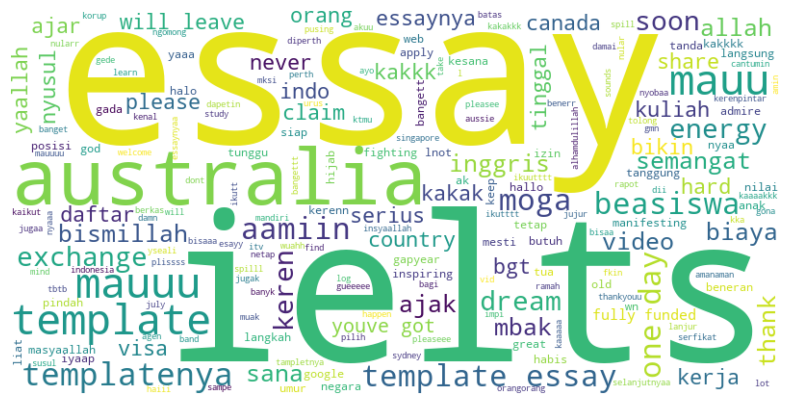

In [11]:
all_text = ' '.join(df['text_final'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Dapat dilihat dari visualisasi work cloud dibawah, bahwa kata yang paling dominan adalah
essay, ielts, template, dan australia.

In [12]:
# Tentukan kolom-kolom yang ingin kamu simpan
kolom_untuk_disimpan = ['waktu_interaksi', 'text_final', 'diggCount', 'replyCommentTotal']

# Simpan DataFrame dengan kolom terpilih ke file CSV baru
df.to_csv('tiktok_bersih.csv', columns=kolom_untuk_disimpan, index=False)

print("File 'tiktok_bersih.csv' berhasil disimpan di folder yang sama dengan notebookmu!")

File 'tiktok_bersih.csv' berhasil disimpan di folder yang sama dengan notebookmu!
